In [1]:
!pip install pandas numpy scikit-learn matplotlib

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "transaction_id": [f"TXN{i:05d}" for i in range(n)],
    "amount": np.random.gamma(shape=2.0, scale=2000, size=n).round(2),
    "account_age_days": np.random.randint(1, 2000, size=n),
    "num_prev_transactions": np.random.randint(0, 500, size=n),
    "device_trust_score": np.random.uniform(0.1, 1.0, size=n).round(2),
    "location_mismatch": np.random.binomial(1, 0.15, size=n),
    "high_risk_merchant": np.random.binomial(1, 0.10, size=n),
    "multiple_failed_attempts": np.random.binomial(1, 0.08, size=n),
    "is_night_transaction": np.random.binomial(1, 0.30, size=n)
})

risk_score = (
    (data["amount"] > 8000).astype(int) * 2 +
    (data["account_age_days"] < 90).astype(int) * 2 +
    (data["num_prev_transactions"] < 5).astype(int) * 1 +
    (data["device_trust_score"] < 0.4).astype(int) * 2 +
    data["location_mismatch"] * 2 +
    data["high_risk_merchant"] * 2 +
    data["multiple_failed_attempts"] * 3 +
    data["is_night_transaction"] * 1
)

fraud_probability = 1 / (1 + np.exp(-(risk_score - 5)))
data["is_fraud"] = np.random.binomial(1, fraud_probability)

data.head()

,transaction_id,amount,account_age_days,num_prev_transactions,device_trust_score,location_mismatch,high_risk_merchant,multiple_failed_attempts,is_night_transaction,is_fraud
0,TXN00000,4787.36,1845,450,0.28,0,0,0,0,0
1,TXN00001,2988.93,1181,398,0.31,0,0,0,1,0
2,TXN00002,2764.57,151,3,0.47,0,0,0,1,1
3,TXN00003,2764.60,1721,236,0.29,0,0,0,0,0
4,TXN00004,9299.43,1202,37,0.67,1,0,0,1,0


In [3]:
data["is_fraud"].value_counts(normalize=True)

,proportion
is_fraud,
0,0.876
1,0.124


In [4]:
data.describe()

,amount,account_age_days,num_prev_transactions,device_trust_score,location_mismatch,high_risk_merchant,multiple_failed_attempts,is_night_transaction,is_fraud
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,4035.079828,1007.348400,248.327600,0.546680,0.15080,0.096000,0.080400,0.297000,0.124000
std,2824.235543,577.963407,144.806698,0.260665,0.35789,0.294621,0.271939,0.456982,0.329615
min,44.500000,1.000000,0.000000,0.100000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,1981.540000,513.750000,122.000000,0.320000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3382.630000,1002.000000,246.000000,0.550000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,5408.715000,1511.500000,374.000000,0.770000,0.00000,0.000000,0.000000,1.000000,0.000000
max,27220.470000,1999.000000,499.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [5]:
data.to_csv("synthetic_fraud_transactions.csv", index=False)
print("Saved synthetic_fraud_transactions.csv")

Saved synthetic_fraud_transactions.csv


In [9]:
from sklearn.model_selection import train_test_split
X = data.drop(columns=["transaction_id", "is_fraud"])
y = data["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, random_state=42)

In [11]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [12]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", round(roc_auc, 4))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       876
           1       0.46      0.61      0.52       124

    accuracy                           0.86      1000
   macro avg       0.70      0.75      0.72      1000
weighted avg       0.88      0.86      0.87      1000

ROC-AUC: 0.834


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[785,  91],
       [ 48,  76]])

In [14]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
3,device_trust_score,0.255239
6,multiple_failed_attempts,0.174416
0,amount,0.170131
1,account_age_days,0.118830
4,location_mismatch,0.089751
2,num_prev_transactions,0.079983
5,high_risk_merchant,0.077658
7,is_night_transaction,0.033992


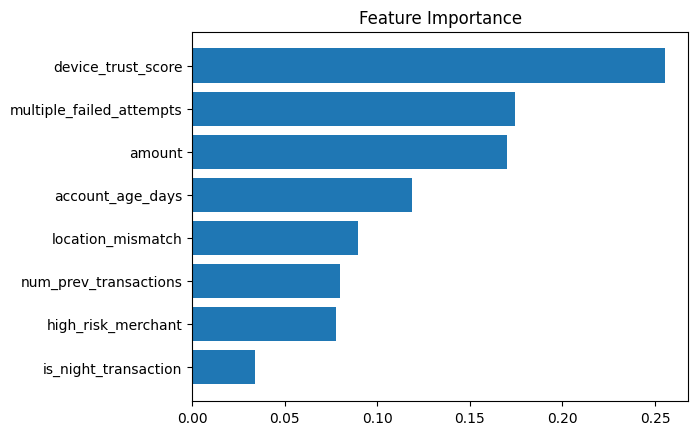

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [18]:
pred_df = X_test.copy()
pred_df["true_label"] = y_test.values
pred_df["pred_label"] = y_pred
pred_df["fraud_probability"] = y_proba
pred_df.head()

,amount,account_age_days,num_prev_transactions,device_trust_score,location_mismatch,high_risk_merchant,multiple_failed_attempts,is_night_transaction,true_label,pred_label,fraud_probability
4523,5214.34,1650,305,0.54,0,0,1,0,0,0,0.421733
618,2511.72,575,309,0.34,0,1,0,1,0,1,0.763649
2287,5200.24,451,265,0.34,0,0,0,0,0,0,0.389757
4220,300.80,1826,255,0.20,0,0,0,0,0,0,0.297809
4196,1652.63,1718,424,0.92,0,0,0,1,0,0,0.156936


In [19]:
def assign_risk_band(prob):
    if prob >= 0.80:
        return "high"
    elif prob >= 0.45:
        return "medium"
    else:
        return "low"

pred_df["risk_band"] = pred_df["fraud_probability"].apply(assign_risk_band)
pred_df[["fraud_probability", "risk_band"]].head()

,fraud_probability,risk_band
4523,0.421733,low
618,0.763649,medium
2287,0.389757,low
4220,0.297809,low
4196,0.156936,low


In [20]:
def route_transaction(prob):
    if prob >= 0.80:
        return "auto_block"
    elif prob >= 0.45:
        return "manual_review"
    else:
        return "auto_approve"

pred_df["route_decision"] = pred_df["fraud_probability"].apply(route_transaction)
pred_df[["fraud_probability", "risk_band", "route_decision"]].head()

,fraud_probability,risk_band,route_decision
4523,0.421733,low,auto_approve
618,0.763649,medium,manual_review
2287,0.389757,low,auto_approve
4220,0.297809,low,auto_approve
4196,0.156936,low,auto_approve


In [21]:
def fallback_risk_flag(row):
    signals = 0

    if row["amount"] > 10000:
        signals += 1
    if row["device_trust_score"] < 0.30:
        signals += 1
    if row["multiple_failed_attempts"] == 1:
        signals += 1
    if row["location_mismatch"] == 1:
        signals += 1
    if row["account_age_days"] < 30:
        signals += 1

    return signals

pred_df["fallback_signal_count"] = pred_df.apply(fallback_risk_flag, axis=1)
pred_df.head()

,amount,account_age_days,num_prev_transactions,device_trust_score,location_mismatch,high_risk_merchant,multiple_failed_attempts,is_night_transaction,true_label,pred_label,fraud_probability,risk_band,route_decision,fallback_signal_count
4523,5214.34,1650,305,0.54,0,0,1,0,0,0,0.421733,low,auto_approve,1
618,2511.72,575,309,0.34,0,1,0,1,0,1,0.763649,medium,manual_review,0
2287,5200.24,451,265,0.34,0,0,0,0,0,0,0.389757,low,auto_approve,0
4220,300.80,1826,255,0.20,0,0,0,0,0,0,0.297809,low,auto_approve,1
4196,1652.63,1718,424,0.92,0,0,0,1,0,0,0.156936,low,auto_approve,0


In [23]:
def final_agentic_decision(row):
    if row["fraud_probability"] >= 0.80:
        return "auto_block"
    elif row["fraud_probability"] >= 0.45:
        if row["fallback_signal_count"] >= 2:
            return "escalated_review"
        return "manual_review"
    else:
        return "auto_approve"

pred_df["final_agentic_decision"] = pred_df.apply(final_agentic_decision, axis=1)
pred_df[["fraud_probability", "route_decision", "fallback_signal_count", "final_agentic_decision"]].head()

,fraud_probability,route_decision,fallback_signal_count,final_agentic_decision
4523,0.421733,auto_approve,1,auto_approve
618,0.763649,manual_review,0,manual_review
2287,0.389757,auto_approve,0,auto_approve
4220,0.297809,auto_approve,1,auto_approve
4196,0.156936,auto_approve,0,auto_approve


In [24]:
routing_summary = pred_df["final_agentic_decision"].value_counts().reset_index()
routing_summary.columns = ["decision", "count"]
routing_summary

,decision,count
0,auto_approve,783
1,manual_review,142
2,escalated_review,64
3,auto_block,11


In [25]:
decision_fraud_summary = pred_df.groupby("final_agentic_decision")["true_label"].agg(["count", "sum", "mean"]).reset_index()
decision_fraud_summary.columns = ["decision", "total_cases", "fraud_cases", "fraud_rate"]
decision_fraud_summary

,decision,total_cases,fraud_cases,fraud_rate
0,auto_approve,783,43,0.054917
1,auto_block,11,8,0.727273
2,escalated_review,64,35,0.546875
3,manual_review,142,38,0.267606


In [26]:
pred_df["baseline_outcome"] = pred_df["pred_label"].map({1: "fraud_flagged", 0: "not_flagged"})

pred_df["agentic_flagged"] = pred_df["final_agentic_decision"].apply(
    lambda x: 1 if x in ["auto_block", "escalated_review", "manual_review"] else 0
)

pred_df[["true_label", "pred_label", "baseline_outcome", "final_agentic_decision", "agentic_flagged"]].head()

,true_label,pred_label,baseline_outcome,final_agentic_decision,agentic_flagged
4523,0,0,not_flagged,auto_approve,0
618,0,1,fraud_flagged,manual_review,1
2287,0,0,not_flagged,auto_approve,0
4220,0,0,not_flagged,auto_approve,0
4196,0,0,not_flagged,auto_approve,0


In [27]:
from sklearn.metrics import recall_score, precision_score, f1_score

baseline_precision = precision_score(y_test, pred_df["pred_label"])
baseline_recall = recall_score(y_test, pred_df["pred_label"])
baseline_f1 = f1_score(y_test, pred_df["pred_label"])

agentic_precision = precision_score(y_test, pred_df["agentic_flagged"])
agentic_recall = recall_score(y_test, pred_df["agentic_flagged"])
agentic_f1 = f1_score(y_test, pred_df["agentic_flagged"])

comparison_metrics = pd.DataFrame([
    {"system": "baseline_model", "precision": baseline_precision, "recall": baseline_recall, "f1_score": baseline_f1},
    {"system": "agentic_pipeline", "precision": agentic_precision, "recall": agentic_recall, "f1_score": agentic_f1},
])

comparison_metrics

,system,precision,recall,f1_score
0,baseline_model,0.455090,0.612903,0.522337
1,agentic_pipeline,0.373272,0.653226,0.475073


In [28]:
pred_df.to_csv("fraud_agentic_predictions.csv", index=False)
routing_summary.to_csv("fraud_routing_summary.csv", index=False)
decision_fraud_summary.to_csv("fraud_decision_summary.csv", index=False)
comparison_metrics.to_csv("fraud_baseline_vs_agentic_metrics.csv", index=False)

print("Saved fraud routing and evaluation outputs.")

Saved fraud routing and evaluation outputs.


In [29]:
feature_importance.to_csv("feature_importance.csv", index=False)
print("Saved feature_importance.csv")

Saved feature_importance.csv


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

baseline_summary = {
    "system": "baseline_model",
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

agentic_summary = {
    "system": "agentic_pipeline",
    "precision": precision_score(y_test, pred_df["agentic_flagged"]),
    "recall": recall_score(y_test, pred_df["agentic_flagged"]),
    "f1_score": f1_score(y_test, pred_df["agentic_flagged"]),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

final_metrics_df = pd.DataFrame([baseline_summary, agentic_summary])
final_metrics_df

,system,precision,recall,f1_score,roc_auc
0,baseline_model,0.455090,0.612903,0.522337,0.834033
1,agentic_pipeline,0.373272,0.653226,0.475073,0.834033


In [31]:
final_metrics_df.to_csv("fraud_baseline_vs_agentic_metrics.csv", index=False)
print("Saved fraud_baseline_vs_agentic_metrics.csv")

Saved fraud_baseline_vs_agentic_metrics.csv


In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

def create_synthetic_data(n=5000, random_state=42):
    np.random.seed(random_state)

    data = pd.DataFrame({
        "transaction_id": [f"TXN{i:05d}" for i in range(n)],
        "amount": np.random.gamma(shape=2.0, scale=2000, size=n).round(2),
        "account_age_days": np.random.randint(1, 2000, size=n),
        "num_prev_transactions": np.random.randint(0, 500, size=n),
        "device_trust_score": np.random.uniform(0.1, 1.0, size=n).round(2),
        "location_mismatch": np.random.binomial(1, 0.15, size=n),
        "high_risk_merchant": np.random.binomial(1, 0.10, size=n),
        "multiple_failed_attempts": np.random.binomial(1, 0.08, size=n),
        "is_night_transaction": np.random.binomial(1, 0.30, size=n)
    })

    risk_score = (
        (data["amount"] > 8000).astype(int) * 2 +
        (data["account_age_days"] < 90).astype(int) * 2 +
        (data["num_prev_transactions"] < 5).astype(int) * 1 +
        (data["device_trust_score"] < 0.4).astype(int) * 2 +
        data["location_mismatch"] * 2 +
        data["high_risk_merchant"] * 2 +
        data["multiple_failed_attempts"] * 3 +
        data["is_night_transaction"] * 1
    )

    fraud_probability = 1 / (1 + np.exp(-(risk_score - 5)))
    data["is_fraud"] = np.random.binomial(1, fraud_probability)
    return data

def assign_risk_band(prob):
    if prob >= 0.80:
        return "high"
    elif prob >= 0.45:
        return "medium"
    return "low"

def route_transaction(prob):
    if prob >= 0.80:
        return "auto_block"
    elif prob >= 0.45:
        return "manual_review"
    return "auto_approve"

def fallback_risk_flag(row):
    signals = 0
    if row["amount"] > 10000:
        signals += 1
    if row["device_trust_score"] < 0.30:
        signals += 1
    if row["multiple_failed_attempts"] == 1:
        signals += 1
    if row["location_mismatch"] == 1:
        signals += 1
    if row["account_age_days"] < 30:
        signals += 1
    return signals

def final_agentic_decision(row):
    if row["fraud_probability"] >= 0.80:
        return "auto_block"
    elif row["fraud_probability"] >= 0.45:
        if row["fallback_signal_count"] >= 2:
            return "escalated_review"
        return "manual_review"
    return "auto_approve"